# Assignment 4 - Solution of Mass and Momentum Equations

In this assignment, the coupled mass and momentum equations are solved for incompressible flow in one-dimensional ducts.

The unknowns are pressure and velocity. Since the density is constant, pressure does not appear directly in the continuity equation. Therefore, pressure and velocity must be coupled so that the pressure field drives the velocity field toward mass conservation.

Water is used as the working fluid:

$$
\rho = 1000 \ \mathrm{kg/m^3}
$$

$$
\mu = 1 \times 10^{-3} \ \mathrm{kg/(m \cdot s)}
$$

In [21]:
import importlib
import Grid

importlib.reload(Grid)

from Grid import Grid

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import norm

from Grid import Grid, CircularDuctGrid
from ScalarCoeffs import ScalarCoeffs
from BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc
from Models import (
    DiffusionModel,
    FirstOrderTransientModel,
    UpwindAdvectionModel,
    CentralAdvectionModel,
    QuickAdvectionModel,
    PressureForceModel,
    WallFrictionModel,
    AdvectingVelocityModel,
    MassConservationEquation
)
from LinearSolver import solve

rho = 1000.0
mu = 1e-3

## Extrapolated Pressure Boundary Condition

For pressure, an extrapolated boundary condition is useful when the pressure at the boundary should follow the internal pressure field instead of being fixed directly.

For a zero-gradient extrapolation, the boundary pressure is set equal to the adjacent internal pressure value.

At the west boundary:

$$
p_W = p_P
$$

At the east boundary:

$$
p_E = p_P
$$

The coefficient is therefore 1 because the boundary value depends directly on the adjacent cell value.

In [23]:
class ExtrapolatedBc:
    """Class defining an extrapolated boundary condition"""

    def __init__(self, phi, grid, loc):
        self._phi = phi
        self._grid = grid
        self._loc = loc

    def value(self):
        if self._loc is BoundaryLocation.WEST:
            return self._phi[1]
        elif self._loc is BoundaryLocation.EAST:
            return self._phi[-2]
        else:
            raise ValueError("Unknown boundary location")

    def coeff(self):
        return 1

    def apply(self):
        if self._loc is BoundaryLocation.WEST:
            self._phi[0] = self._phi[1]
        elif self._loc is BoundaryLocation.EAST:
            self._phi[-1] = self._phi[-2]
        else:
            raise ValueError("Unknown boundary location")

# Problem 1

For a constant-area duct with no wall friction,

$$
\tau_w = 0
$$

the exact solution is a uniform velocity and uniform pressure field.

The assignment specifies:

$$
u = 10 \ \mathrm{m/s}
$$

and

$$
p = 0 \ \mathrm{Pa}
$$

everywhere as the initial condition.

Since there is no pressure gradient, no wall friction, and no area change, the governing equations are already satisfied exactly.

The purpose of this test is to verify that:

1. The coupled pressure-velocity solver accepts the exact solution.
2. The Rhie-Chow pressure-velocity coupling is implemented correctly.
3. The solution is independent of flow direction.

The problem will be solved twice:

- Case A: $$u = 10 \ \mathrm{m/s}$$
- Case B: $$u = -10 \ \mathrm{m/s}$$

The resulting pressure and velocity fields should remain unchanged after one timestep.

## Boundary Conditions

The velocity is specified at the inlet using a Dirichlet boundary condition,

$$
u = u_{in}
$$

while a zero-gradient condition is applied at the outlet,

$$
\frac{\partial u}{\partial x}=0
$$

The pressure is fixed at the outlet,

$$
p = 0
$$

and an extrapolated boundary condition is applied at the inlet,

$$
\frac{\partial p}{\partial x}=0
$$

implemented using the ExtrapolatedBc class.

For positive flow, the inlet is located at the west boundary and the outlet at the east boundary. For negative flow, the boundary conditions are reversed so that the velocity is always specified at the inflow boundary and the pressure is always specified at the outflow boundary.

This ensures that the solver is independent of flow direction and provides a useful verification test for the pressure-velocity coupling implementation.

## Solver Implementation

A reusable function, `solve_problem1`, is created to assemble and solve the coupled mass and momentum equations.

The function performs the following steps:

1. Creates the computational grid.
2. Initializes the pressure and velocity fields.
3. Applies the appropriate inlet and outlet boundary conditions.
4. Assembles the momentum equation, including transient, diffusion, advection, and pressure-force terms.
5. Computes the Rhie-Chow advecting velocity used for pressure-velocity coupling.
6. Assembles the mass conservation equation.
7. Solves the coupled pressure-velocity correction system.
8. Iterates until both the mass and momentum residuals satisfy the convergence criterion.

The same solver will be reused throughout the assignment with modifications to account for wall friction and varying duct geometry.

In [24]:
def solve_problem1(U0,
                   P0=0.0,
                   ncv=10,
                   dt=1e9,
                   maxIter=100,
                   converged=1e-8,
                   verbose=True):
    
    # Geometry
    lx = 4.0
    ly = 0.02
    lz = 0.02
    grid = Grid(lx, ly, lz, ncv)

    # Coefficients
    PP_coeffs = ScalarCoeffs(grid.ncv)
    PU_coeffs = ScalarCoeffs(grid.ncv)
    UP_coeffs = ScalarCoeffs(grid.ncv)
    UU_coeffs = ScalarCoeffs(grid.ncv)

    # Initial fields
    U = U0*np.ones(grid.ncv + 2)
    P = P0*np.ones(grid.ncv + 2)
    Uold = np.copy(U)

    # Advecting velocity and Rhie-Chow damping coefficient
    Uhe = U0*np.ones(grid.ncv + 1)
    dhat = np.zeros(grid.ncv + 1)

    # Boundary conditions depend on flow direction
    if U0 > 0:
        U_west_bc = DirichletBc(U, grid, U0, BoundaryLocation.WEST)
        U_east_bc = NeumannBc(U, grid, 0.0, BoundaryLocation.EAST)

        P_west_bc = ExtrapolatedBc(P, grid, BoundaryLocation.WEST)
        P_east_bc = DirichletBc(P, grid, P0, BoundaryLocation.EAST)

    else:
        U_west_bc = NeumannBc(U, grid, 0.0, BoundaryLocation.WEST)
        U_east_bc = DirichletBc(U, grid, U0, BoundaryLocation.EAST)

        P_west_bc = DirichletBc(P, grid, P0, BoundaryLocation.WEST)
        P_east_bc = ExtrapolatedBc(P, grid, BoundaryLocation.EAST)

    # Apply boundary conditions
    U_west_bc.apply()
    U_east_bc.apply()
    P_west_bc.apply()
    P_east_bc.apply()

    # Models
    transient = FirstOrderTransientModel(grid, U, Uold, rho, 1.0, dt)
    diffusion = DiffusionModel(grid, U, mu, U_west_bc, U_east_bc)
    advection = UpwindAdvectionModel(grid, U, Uhe, rho, 1.0, U_west_bc, U_east_bc)
    pressure = PressureForceModel(grid, P, P_west_bc, P_east_bc)
    advecting = AdvectingVelocityModel(grid, dhat, Uhe, P, U, UU_coeffs)
    mass = MassConservationEquation(grid, U, P, dhat, Uhe, rho,
                                    P_west_bc, P_east_bc,
                                    U_west_bc, U_east_bc)

    # Nonlinear iteration
    for i in range(maxIter):

        PP_coeffs.zero()
        PU_coeffs.zero()
        UP_coeffs.zero()
        UU_coeffs.zero()

        # Momentum equation
        UU_coeffs = diffusion.add(UU_coeffs)
        UU_coeffs = advection.add(UU_coeffs)
        UU_coeffs = transient.add(UU_coeffs)
        UP_coeffs = pressure.add(UP_coeffs)

        # Mass equation
        advecting.update()
        PP_coeffs, PU_coeffs = mass.add(PP_coeffs, PU_coeffs)

        # Residuals
        mass_resid = norm(PP_coeffs.rP + PU_coeffs.rP, np.inf)
        mom_resid = norm(UP_coeffs.rP + UU_coeffs.rP, np.inf)

        if verbose:
            print(f"Iteration {i}: Mass residual = {mass_resid:.3e}, Momentum residual = {mom_resid:.3e}")

        if mass_resid < converged and mom_resid < converged:
            break

        # Coupled correction solve
        dP, dU = solve(PP_coeffs, PU_coeffs, UP_coeffs, UU_coeffs)

        P[1:-1] += dP
        U[1:-1] += dU

        # Update boundary values
        U_west_bc.apply()
        U_east_bc.apply()
        P_west_bc.apply()
        P_east_bc.apply()

        advecting.update()

    return grid, U, P, Uhe, dhat, i, mass_resid, mom_resid

## Positive Flow Verification

The first verification case uses positive flow from west to east.

Since the initial condition is already the exact solution, the solver should converge immediately or after very few iterations. The velocity should remain equal to 10 m/s and the pressure should remain equal to 0 Pa.

In [25]:
grid_pos, U_pos, P_pos, Uhe_pos, dhat_pos, it_pos, mres_pos, ures_pos = solve_problem1(
    U0=10.0,
    verbose=False
)

print("\nPositive flow results")
print("Iterations:", it_pos)
print("Maximum velocity change from 10 m/s:", np.max(np.abs(U_pos - 10.0)))
print("Maximum pressure magnitude:", np.max(np.abs(P_pos)))
print("Final mass residual:", mres_pos)
print("Final momentum residual:", ures_pos)


Positive flow results
Iterations: 0
Maximum velocity change from 10 m/s: 0.0
Maximum pressure magnitude: 0.0
Final mass residual: 0.0
Final momentum residual: 0.0


## Negative Flow Verification

The second verification case uses negative flow from east to west.

The governing equations are unchanged, but the inlet and outlet boundaries are reversed automatically inside the solver. The velocity boundary condition is applied at the inflow boundary, while the pressure boundary condition is applied at the outflow boundary.

Since the initial condition is again the exact solution,

$$
u = -10 \ \mathrm{m/s}
$$

and

$$
p = 0 \ \mathrm{Pa}
$$

throughout the domain, the solver should preserve the solution without modification.

Agreement between the positive-flow and negative-flow cases demonstrates that the implementation is independent of flow direction.

In [26]:
grid_neg, U_neg, P_neg, Uhe_neg, dhat_neg, it_neg, mres_neg, ures_neg = solve_problem1(
    U0=-10.0,
    verbose=False
)

print("\nNegative flow results")
print("Iterations:", it_neg)
print("Maximum velocity change from -10 m/s:", np.max(np.abs(U_neg + 10.0)))
print("Maximum pressure magnitude:", np.max(np.abs(P_neg)))
print("Final mass residual:", mres_neg)
print("Final momentum residual:", ures_neg)


Negative flow results
Iterations: 0
Maximum velocity change from -10 m/s: 0.0
Maximum pressure magnitude: 0.0
Final mass residual: 0.0
Final momentum residual: 0.0


## Problem 1 Plots

The velocity and pressure fields are plotted for both flow directions. For this verification problem, the velocity field should remain uniform and the pressure field should remain zero throughout the duct.

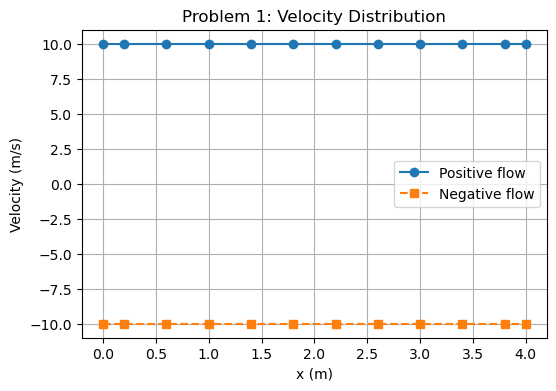

In [27]:
plt.figure(figsize=(6,4))

plt.plot(grid_pos.xP, U_pos, 'o-', label='Positive flow')
plt.plot(grid_neg.xP, U_neg, 's--', label='Negative flow')

plt.xlabel('x (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Problem 1: Velocity Distribution')
plt.grid()
plt.legend()

plt.show()

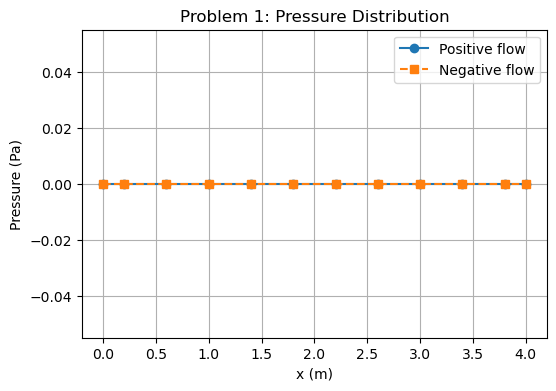

In [28]:
plt.figure(figsize=(6,4))

plt.plot(grid_pos.xP, P_pos, 'o-', label='Positive flow')
plt.plot(grid_neg.xP, P_neg, 's--', label='Negative flow')

plt.xlabel('x (m)')
plt.ylabel('Pressure (Pa)')
plt.title('Problem 1: Pressure Distribution')
plt.grid()
plt.legend()

plt.show()

## Results and Discussion

Both the positive-flow and negative-flow cases converged immediately with zero mass and momentum residuals.

The velocity remained constant throughout the domain at the prescribed values of 10 m/s and -10 m/s, respectively, while the pressure remained equal to 0 Pa everywhere.

These results are expected because the initial conditions are already the exact solution of the governing equations for a constant-area duct with no wall friction. Since the momentum and continuity equations are satisfied exactly, no corrections are required and the solver converges immediately.

The identical results obtained for both flow directions confirm that the implementation is independent of flow direction and that the pressure-velocity coupling is functioning correctly.

# Problem 2

In this problem, turbulent wall friction is included in the momentum equation. The resulting wall shear stress produces a pressure drop along the duct while the velocity remains nearly constant due to the constant cross-sectional area.

The friction coefficient is calculated using

$$
C_f=\left(1.58\ln(Re)-3.28\right)^{-2}
$$

where

$$
Re=\frac{\rho D_h U}{\mu}
$$

and

$$
D_h=\frac{4A}{P_o}
$$

is the hydraulic diameter.

The wall friction force is modeled as

$$
F_w=\frac12 \rho C_f U^2 A_o
$$

where \(A_o\) is the wetted wall area of each control volume.

The Reynolds-number dependence of the friction coefficient is treated explicitly, while the velocity-squared term is linearized and treated implicitly.

## Solver Modifications

The solver developed for Problem 1 is reused with the addition of the wall-friction source term.

The momentum equation now contains:

- transient term
- advection term
- diffusion term
- pressure-force term
- wall-friction term

The pressure-velocity coupling procedure remains unchanged.

In [29]:
def solve_problem2(U0,
                   P0=0.0,
                   ncv=10,
                   dt=1e9,
                   maxIter=100,
                   converged=1e-8,
                   verbose=True):
    
    # Geometry
    lx = 4.0
    ly = 0.02
    lz = 0.02
    grid = Grid(lx, ly, lz, ncv)

    # Coefficients
    PP_coeffs = ScalarCoeffs(grid.ncv)
    PU_coeffs = ScalarCoeffs(grid.ncv)
    UP_coeffs = ScalarCoeffs(grid.ncv)
    UU_coeffs = ScalarCoeffs(grid.ncv)

    # Initial fields
    U = U0*np.ones(grid.ncv + 2)
    P = P0*np.ones(grid.ncv + 2)
    Uold = np.copy(U)

    # Advecting velocity and Rhie-Chow damping coefficient
    Uhe = U0*np.ones(grid.ncv + 1)
    dhat = np.zeros(grid.ncv + 1)

    # Boundary conditions depend on flow direction
    if U0 > 0:
        U_west_bc = DirichletBc(U, grid, U0, BoundaryLocation.WEST)
        U_east_bc = NeumannBc(U, grid, 0.0, BoundaryLocation.EAST)

        P_west_bc = ExtrapolatedBc(P, grid, BoundaryLocation.WEST)
        P_east_bc = DirichletBc(P, grid, P0, BoundaryLocation.EAST)

    else:
        U_west_bc = NeumannBc(U, grid, 0.0, BoundaryLocation.WEST)
        U_east_bc = DirichletBc(U, grid, U0, BoundaryLocation.EAST)

        P_west_bc = DirichletBc(P, grid, P0, BoundaryLocation.WEST)
        P_east_bc = ExtrapolatedBc(P, grid, BoundaryLocation.EAST)

    # Apply boundary conditions
    U_west_bc.apply()
    U_east_bc.apply()
    P_west_bc.apply()
    P_east_bc.apply()

    # Models
    transient = FirstOrderTransientModel(grid, U, Uold, rho, 1.0, dt)
    diffusion = DiffusionModel(grid, U, mu, U_west_bc, U_east_bc)
    advection = UpwindAdvectionModel(grid, U, Uhe, rho, 1.0, U_west_bc, U_east_bc)
    pressure = PressureForceModel(grid, P, P_west_bc, P_east_bc)
    wall_friction = WallFrictionModel(grid, U, rho, mu)
    advecting = AdvectingVelocityModel(grid, dhat, Uhe, P, U, UU_coeffs)
    mass = MassConservationEquation(grid, U, P, dhat, Uhe, rho,
                                    P_west_bc, P_east_bc,
                                    U_west_bc, U_east_bc)

    # Nonlinear iteration
    for i in range(maxIter):

        PP_coeffs.zero()
        PU_coeffs.zero()
        UP_coeffs.zero()
        UU_coeffs.zero()

        # Momentum equation
        UU_coeffs = diffusion.add(UU_coeffs)
        UU_coeffs = advection.add(UU_coeffs)
        UU_coeffs = transient.add(UU_coeffs)
        UU_coeffs = wall_friction.add(UU_coeffs)
        
        UP_coeffs = pressure.add(UP_coeffs)

        # Mass equation
        advecting.update()
        PP_coeffs, PU_coeffs = mass.add(PP_coeffs, PU_coeffs)

        # Residuals
        mass_resid = norm(PP_coeffs.rP + PU_coeffs.rP, np.inf)
        mom_resid = norm(UP_coeffs.rP + UU_coeffs.rP, np.inf)

        if verbose:
            print(f"Iteration {i}: Mass residual = {mass_resid:.3e}, Momentum residual = {mom_resid:.3e}")

        if mass_resid < converged and mom_resid < converged:
            break

        # Coupled correction solve
        dP, dU = solve(PP_coeffs, PU_coeffs, UP_coeffs, UU_coeffs)

        P[1:-1] += dP
        U[1:-1] += dU

        # Update boundary values
        U_west_bc.apply()
        U_east_bc.apply()
        P_west_bc.apply()
        P_east_bc.apply()

        advecting.update()

    return grid, U, P, Uhe, dhat, i, mass_resid, mom_resid

In [30]:
grid_p2, U_p2, P_p2, Uhe_p2, dhat_p2, it_p2, mres_p2, ures_p2 = solve_problem2(
    U0=10.0,
    verbose=True
)

print("\nProblem 2 results")
print("Iterations:", it_p2)
print("Final mass residual:", mres_p2)
print("Final momentum residual:", ures_p2)
print("Inlet pressure:", P_p2[0])
print("Outlet pressure:", P_p2[-1])
print("Pressure drop:", P_p2[0] - P_p2[-1])

Iteration 0: Mass residual = 0.000e+00, Momentum residual = 6.246e+00
Iteration 1: Mass residual = 6.033e-01, Momentum residual = 6.297e-01
Iteration 2: Mass residual = 1.860e-01, Momentum residual = 7.753e-02
Iteration 3: Mass residual = 4.157e-02, Momentum residual = 2.426e-02
Iteration 4: Mass residual = 1.547e-02, Momentum residual = 5.918e-03
Iteration 5: Mass residual = 5.515e-03, Momentum residual = 1.307e-03
Iteration 6: Mass residual = 2.188e-03, Momentum residual = 6.624e-04
Iteration 7: Mass residual = 8.113e-04, Momentum residual = 3.645e-04
Iteration 8: Mass residual = 3.318e-04, Momentum residual = 1.389e-04
Iteration 9: Mass residual = 1.355e-04, Momentum residual = 5.907e-05
Iteration 10: Mass residual = 4.865e-05, Momentum residual = 2.105e-05
Iteration 11: Mass residual = 2.206e-05, Momentum residual = 9.746e-06
Iteration 12: Mass residual = 8.622e-06, Momentum residual = 4.311e-06
Iteration 13: Mass residual = 3.903e-06, Momentum residual = 1.579e-06
Iteration 14: Ma

## Problem 2 Plots

The velocity and pressure distributions are plotted after convergence. For a constant-area duct, mass conservation requires the velocity to remain nearly uniform. Wall friction is balanced by a pressure gradient, so pressure should decrease approximately linearly in the flow direction.

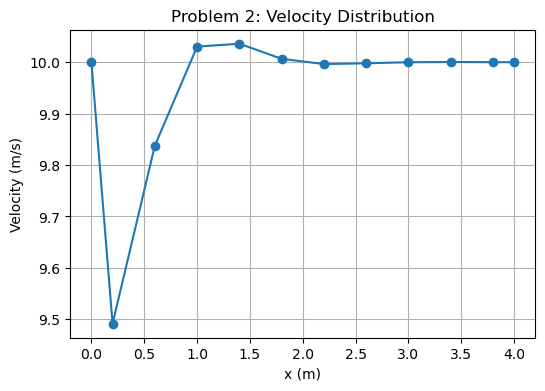

In [31]:
plt.figure(figsize=(6,4))

plt.plot(grid_p2.xP, U_p2, 'o-')

plt.xlabel('x (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Problem 2: Velocity Distribution')
plt.grid()

plt.show()

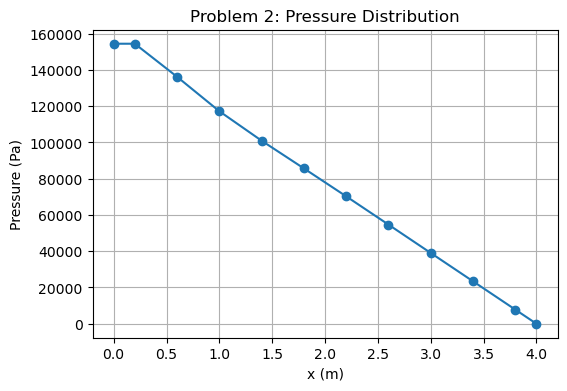

In [32]:
plt.figure(figsize=(6,4))

plt.plot(grid_p2.xP, P_p2, 'o-')

plt.xlabel('x (m)')
plt.ylabel('Pressure (Pa)')
plt.title('Problem 2: Pressure Distribution')
plt.grid()

plt.show()

## Results and Discussion

The solver converged in 20 iterations with mass and momentum residuals below the specified tolerance.

The velocity remained approximately constant at 10 m/s throughout the duct, as expected for incompressible flow in a constant-area duct.

The pressure decreased from approximately 154 kPa at the inlet to 0 Pa at the outlet. The nearly linear pressure profile indicates that the pressure gradient balances the wall-friction losses along the duct.

Unlike Problem 1, the initial condition is not an exact solution because wall friction is present. Consequently, several iterations are required to establish the pressure field needed to balance the frictional resistance.

## Analytical Pressure Drop Check

For a constant-area duct with nearly uniform velocity, the friction force per control volume can be calculated directly from the wall shear model.

The friction coefficient is

$$
C_f=\left(1.58\ln(Re)-3.28\right)^{-2}
$$

with

$$
Re=\frac{\rho D_h U}{\mu}
$$

The total pressure drop is obtained by balancing the total wall-friction force with the pressure force over the duct cross-sectional area.

In [33]:
# Analytical pressure drop for Problem 2

lx = 4.0
ly = 0.02
lz = 0.02
U_exact = 10.0

A = ly*lz
Po = 2.0*(ly + lz)
Dh = 4.0*A/Po

Re = rho*Dh*U_exact/mu
Cf = (1.58*np.log(Re) - 3.28)**(-2)

Ao_total = Po*lx
F_total = 0.5*rho*Cf*U_exact**2*Ao_total

deltaP_exact = F_total/A
deltaP_num = P_p2[0] - P_p2[-1]

print("Hydraulic diameter:", Dh)
print("Reynolds number:", Re)
print("Friction coefficient:", Cf)
print("Analytical pressure drop:", deltaP_exact)
print("Numerical pressure drop:", deltaP_num)
print("Absolute error:", abs(deltaP_num - deltaP_exact))
print("Relative error (%):", abs(deltaP_num - deltaP_exact)/deltaP_exact*100)

Hydraulic diameter: 0.02
Reynolds number: 200000.0
Friction coefficient: 0.00390351960606262
Analytical pressure drop: 156140.7842425048
Numerical pressure drop: 154472.71524937515
Absolute error: 1668.068993129651
Relative error (%): 1.068310884450885


## Analytical Comparison

The analytical pressure drop calculated from the wall-friction correlation is 156.14 kPa, while the numerical pressure drop is 154.47 kPa. The relative difference is approximately 1.07%.

This small difference is reasonable because the numerical velocity is not perfectly uniform near the boundaries. Since the wall-friction coefficient and friction force depend on velocity, these small velocity variations slightly change the computed pressure drop.

The result is not correct after the first iteration because the initial pressure field is uniform. Several iterations are needed for the coupled solver to develop the pressure gradient that balances the wall-friction force.

# Problem 3

In this problem, flow through a frictionless converging-diverging circular duct is solved.

The duct radius is given by

$$
r = 2H_t + H_t\cos\left(2\pi\frac{x}{L}\right)
$$

where

$$
L = 1 \ \mathrm{m}
$$

and

$$
H_t = 0.01 \ \mathrm{m}
$$

Since the duct is frictionless, the wall-friction model is not included. The purpose of this problem is to compare UDS, CDS, and QUICK advection schemes for the momentum equation.

For an ideal frictionless duct, the dynamic head loss should approach zero as the numerical solution improves.

## Higher-Order Momentum Advection Schemes

For Problem 3, UDS, CDS, and QUICK are compared in the momentum equation.

UDS is first-order accurate and stable, but it introduces numerical diffusion. CDS and QUICK are higher-order schemes, so they should reduce numerical diffusion and produce a smaller artificial pressure loss in the frictionless duct.

The higher-order schemes are implemented using deferred correction. The linearization is still based on UDS for stability, while the difference between the higher-order face value and the UDS face value is added explicitly to the residual.

## Problem 3 Solver

The Problem 2 solver is modified for the converging-diverging duct.

The main changes are:

1. The grid is replaced by `CircularDuctGrid`.
2. Wall friction is removed.
3. The inlet velocity is fixed at 2 m/s.
4. The outlet pressure is fixed at 0 Pa.
5. The momentum advection scheme is selected using the input argument `scheme`.

In [37]:
def solve_problem3(ncv=8,
                   scheme="UDS",
                   U0=2.0,
                   P0=0.0,
                   dt=1e9,
                   maxIter=300,
                   converged=1e-8,
                   verbose=False):
    
    # Geometry
    lx = 1.0
    Ht = 0.01
    grid = CircularDuctGrid(lx, Ht, ncv)

    # Coefficients
    PP_coeffs = ScalarCoeffs(grid.ncv)
    PU_coeffs = ScalarCoeffs(grid.ncv)
    UP_coeffs = ScalarCoeffs(grid.ncv)
    UU_coeffs = ScalarCoeffs(grid.ncv)

    # Initial velocity from approximate mass conservation
    A_in = grid.Af[0]

    rP = 2.0*0.01 + 0.01*np.cos(2.0*np.pi*grid.xP[1:-1]/1.0)
    AP = np.pi*rP**2

    U_internal = U0*A_in/AP

    U = np.zeros(grid.ncv + 2)
    U[0] = U0
    U[1:-1] = U_internal
    U[-1] = U_internal[-1]

    P = P0*np.ones(grid.ncv + 2)
    Uold = np.copy(U)

    # Advecting velocity
    Uhe = U0*A_in/grid.Af
    dhat = np.zeros(grid.ncv + 1)

    # Boundary conditions
    U_west_bc = DirichletBc(U, grid, U0, BoundaryLocation.WEST)
    U_east_bc = NeumannBc(U, grid, 0.0, BoundaryLocation.EAST)

    P_west_bc = ExtrapolatedBc(P, grid, BoundaryLocation.WEST)
    P_east_bc = DirichletBc(P, grid, P0, BoundaryLocation.EAST)

    U_west_bc.apply()
    U_east_bc.apply()
    P_west_bc.apply()
    P_east_bc.apply()

    # Models
    transient = FirstOrderTransientModel(grid, U, Uold, rho, 1.0, dt)
    diffusion = DiffusionModel(grid, U, mu, U_west_bc, U_east_bc)

    if scheme == "UDS":
        advection = UpwindAdvectionModel(grid, U, Uhe, rho, 1.0, U_west_bc, U_east_bc)
    elif scheme == "CDS":
        advection = CentralAdvectionModel(grid, U, Uhe, rho, 1.0, U_west_bc, U_east_bc)
    elif scheme == "QUICK":
        advection = QuickAdvectionModel(grid, U, Uhe, rho, 1.0, U_west_bc, U_east_bc)
    else:
        raise ValueError("scheme must be 'UDS', 'CDS', or 'QUICK'")

    pressure = PressureForceModel(grid, P, P_west_bc, P_east_bc)
    advecting = AdvectingVelocityModel(grid, dhat, Uhe, P, U, UU_coeffs)

    mass = MassConservationEquation(grid, U, P, dhat, Uhe, rho,
                                    P_west_bc, P_east_bc,
                                    U_west_bc, U_east_bc)

    for i in range(maxIter):

        PP_coeffs.zero()
        PU_coeffs.zero()
        UP_coeffs.zero()
        UU_coeffs.zero()

        UU_coeffs = diffusion.add(UU_coeffs)
        UU_coeffs = advection.add(UU_coeffs)
        UU_coeffs = transient.add(UU_coeffs)

        UP_coeffs = pressure.add(UP_coeffs)

        advecting.update()
        PP_coeffs, PU_coeffs = mass.add(PP_coeffs, PU_coeffs)

        mass_resid = norm(PP_coeffs.rP + PU_coeffs.rP, np.inf)
        mom_resid = norm(UP_coeffs.rP + UU_coeffs.rP, np.inf)

        if verbose:
            print(f"{scheme}, ncv={ncv}, iteration {i}: mass={mass_resid:.3e}, momentum={mom_resid:.3e}")

        if mass_resid < converged and mom_resid < converged:
            break

        dP, dU = solve(PP_coeffs, PU_coeffs, UP_coeffs, UU_coeffs)

        P[1:-1] += dP
        U[1:-1] += dU

        U_west_bc.apply()
        U_east_bc.apply()
        P_west_bc.apply()
        P_east_bc.apply()

        advecting.update()

    CD = (P[0] - P[-1])/(0.5*rho*U0**2)

    return grid, U, P, Uhe, dhat, CD, i, mass_resid, mom_resid

## Grid and Scheme Comparison

The duct is solved using 8, 16, 32, and 64 control volumes. For each grid, UDS, CDS, and QUICK are tested.

The dynamic head loss coefficient is calculated as

$$
C_D = \frac{P_{in}-P_{out}}{\frac{1}{2}\rho U_{in}^2}
$$

For a frictionless duct, the physical dynamic head loss should approach zero. Any nonzero value of \(C_D\) is therefore numerical loss.

In [40]:
schemes = ["UDS", "CDS", "QUICK"]
ncvs = [8, 16, 32, 64]

problem3_results = {}

for scheme in schemes:
    problem3_results[scheme] = {}
    
    for ncv in ncvs:
        grid, U, P, Uhe, dhat, CD, iterations, mass_resid, mom_resid = solve_problem3(
            ncv=ncv,
            scheme=scheme,
            verbose=False
        )
        
        problem3_results[scheme][ncv] = {
            "grid": grid,
            "U": U,
            "P": P,
            "Uhe": Uhe,
            "CD": CD,
            "iterations": iterations,
            "mass_resid": mass_resid,
            "mom_resid": mom_resid
        }
        
        print(
            f"{scheme}, ncv={ncv}: "
            f"C_D={CD:.6e}, iterations={iterations}, "
            f"mass={mass_resid:.2e}, momentum={mom_resid:.2e}"
        )

UDS, ncv=8: C_D=4.690345e+01, iterations=63, mass=4.45e-09, momentum=2.29e-09
UDS, ncv=16: C_D=2.923312e+01, iterations=31, mass=6.77e-09, momentum=7.40e-09
UDS, ncv=32: C_D=1.409467e+01, iterations=32, mass=7.92e-09, momentum=1.56e-09
UDS, ncv=64: C_D=6.844620e+00, iterations=27, mass=7.77e-09, momentum=2.81e-09


C:\Users\smohsen7\Documents\GitHub\9710_2026\Lesson5\LinearSolver.py:117: MatrixRankWarning: Matrix is exactly singular
  res = spsolve(A,b)


CDS, ncv=8: C_D=nan, iterations=299, mass=nan, momentum=nan
CDS, ncv=16: C_D=4.100200e+00, iterations=117, mass=1.26e-09, momentum=8.34e-09
CDS, ncv=32: C_D=5.652786e-01, iterations=139, mass=1.68e-09, momentum=8.52e-09
CDS, ncv=64: C_D=7.125199e-02, iterations=216, mass=1.69e-09, momentum=9.94e-09
QUICK, ncv=8: C_D=2.427752e+01, iterations=299, mass=2.48e-03, momentum=5.09e-02
QUICK, ncv=16: C_D=6.092729e+00, iterations=41, mass=3.27e-09, momentum=5.97e-09
QUICK, ncv=32: C_D=8.089140e-01, iterations=45, mass=6.50e-09, momentum=7.08e-09
QUICK, ncv=64: C_D=9.812309e-02, iterations=40, mass=7.35e-09, momentum=9.06e-09


## Dynamic Head Loss Coefficient

The dynamic head loss coefficient (\(C_D\)) was calculated for each advection scheme and grid resolution using the numerical pressure and velocity fields obtained from the simulation.

For the frictionless duct considered in this problem, the exact solution predicts no head loss, corresponding to

$$
C_D = 0.
$$

Therefore, any non-zero value of \(C_D\) represents numerical dissipation introduced by the discretization scheme. The computed values are summarized in Table X.

In [47]:
import pandas as pd

cd_table = pd.DataFrame(
    {
        "UDS": [problem3_results["UDS"][n]["CD"] for n in ncvs],
        "CDS": [problem3_results["CDS"][n]["CD"] for n in ncvs],
        "QUICK": [problem3_results["QUICK"][n]["CD"] for n in ncvs],
    },
    index=ncvs
)

cd_table.index.name = "Number of CVs"
cd_table

,UDS,CDS,QUICK
Number of CVs,,,
8,46.903449,NaN,24.277515
16,29.233115,4.100200,6.092729
32,14.094667,0.565279,0.808914
64,6.844620,0.071252,0.098123


As the grid is refined, the computed \(C_D\) values approach zero, indicating a reduction in numerical losses and improved agreement with the analytical solution.

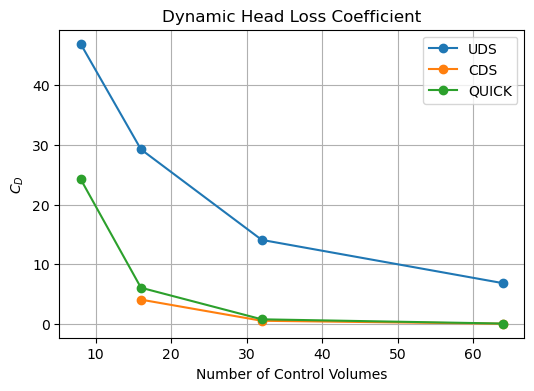

In [42]:
plt.figure(figsize=(6,4))

for scheme in schemes:

    CDs = [
        problem3_results[scheme][ncv]["CD"]
        for ncv in ncvs
    ]

    plt.plot(ncvs, CDs, marker='o', label=scheme)

plt.xlabel("Number of Control Volumes")
plt.ylabel(r"$C_D$")
plt.title("Dynamic Head Loss Coefficient")
plt.grid()
plt.legend()

plt.show()

## Velocity and Pressure Distributions

The velocity and pressure distributions for the finest grid are plotted to compare the behavior of the different advection schemes.

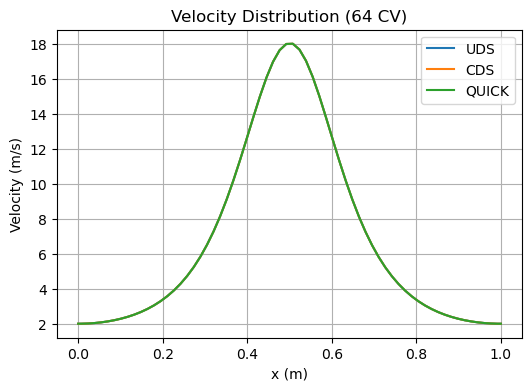

In [43]:
plt.figure(figsize=(6,4))

for scheme in schemes:
    
    grid = problem3_results[scheme][64]["grid"]
    U = problem3_results[scheme][64]["U"]

    plt.plot(grid.xP, U, label=scheme)

plt.xlabel("x (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity Distribution (64 CV)")
plt.grid()
plt.legend()

plt.show()

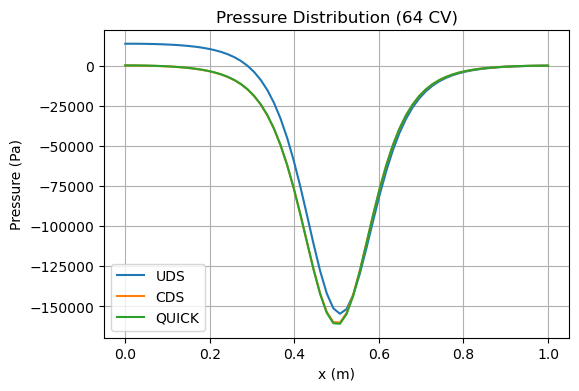

In [44]:
plt.figure(figsize=(6,4))

for scheme in schemes:
    
    grid = problem3_results[scheme][64]["grid"]
    P = problem3_results[scheme][64]["P"]

    plt.plot(grid.xP, P, label=scheme)

plt.xlabel("x (m)")
plt.ylabel("Pressure (Pa)")
plt.title("Pressure Distribution (64 CV)")
plt.grid()
plt.legend()

plt.show()

## Results and Discussion

The velocity increased as the duct contracted and reached a maximum value at the throat, where the cross-sectional area was smallest. The pressure decreased as the flow accelerated and recovered in the diverging section. These trends are consistent with mass conservation and Bernoulli's principle for frictionless flow.

The dynamic head loss coefficient decreased with grid refinement for all advection schemes, indicating that the numerical solution approached the theoretical value of

$$
C_D = 0.
$$

UDS produced the largest dynamic head loss because of its higher numerical diffusion. CDS and QUICK converged more rapidly toward zero and therefore provided more accurate solutions on coarse and intermediate grids.

The CDS scheme failed on the coarsest grid because central differencing is less stable when the mesh is too coarse. QUICK produced smaller numerical losses than UDS, but still showed noticeable error on the coarsest mesh and converged successfully on finer grids.

Overall, CDS and QUICK produced significantly smaller numerical losses than UDS and better represented the frictionless flow behavior of the converging-diverging duct.

The CDS solution for the 8-control-volume grid did not converge and produced a singular matrix. This behavior is consistent with the reduced stability of central differencing on very coarse meshes.